# Paper experiments

One environment per notebook, chosen in the settings cell. Outputs (figure PDFs, CSV tables,
per-repetition results, manifest) go to `analysis/results/variants/<exploration tag>/<benchmark>/<roster>/`,
or `analysis/results/<benchmark>/<roster>/` without forced exploration.

1. Providers and environment
2. One pass, paired over policies
3. Long horizon
4. Regret and bounds
5. Payments and payoffs
6. Manifest
7. Cross-environment summary

Monetary quantities are in units of $10^{-6}$ USD. Generation cost (private), query price
(tokens times listed price), bid and critical payment are kept apart. The amount paid is the
critical payment for the mechanism, plus $C_{\max}$ on forced rounds, and the query price for
the listed-price policies.

In [1]:
BENCHMARK = "GPQA"         # "GSM8K" or "GPQA"
ROSTER = "ladder"          # "full", "ladder" or "strong" (configs/default.toml)
T_LONG = 70_000            # rounds of the long-horizon run
QUICK = False              # True: 3 repetitions and 20,000 rounds, to check the notebook
CONFIG_FILE = "configs/default.toml"  # environment definitions
ENVIRONMENT = None         # an environment id of CONFIG_FILE; None selects by BENCHMARK and ROSTER
EXPLORATION = "count"      # "count": count-based forced exploration of the mechanism arm; "none": the mechanism as published
EXPLORATION_SCALE = 2.0    # g(t) = ceil(EXPLORATION_SCALE * (t / n) ** EXPLORATION_ALPHA)
EXPLORATION_ALPHA = 0.75   # in (0, 1)


## Setup

Imports, configuration, output directory, plot style, helpers.

In [2]:
from pathlib import Path
from dataclasses import replace
from fractions import Fraction
from datetime import datetime, timezone
import csv
import json
import shutil
import subprocess
import sys

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(ROOT))

from cri.config import ExplorationConfig, load_config
from cri.experiment import prepare_environment, episode_seed, draw_seed, resolve_arm
from cri.simulate import simulate_episode
from cri.metrics import evaluate, exploration_events, exploration_metrics, window, theory_constants, bounds, M_count, L_count, forced_cap, selection_caps, B_id_at
from cri.baselines import make_policy, make_payment_rule
from cri.exploration import describe, make_exploration
from cri.pricing import MODEL_PRICE_PER_1M, invoice as public_invoice
from cri.variants import parse_variant, price_rate

REPS = 3 if QUICK else 30        # paired repetitions of the one-pass experiment
LONG_REPS = 2 if QUICK else 30   # repetitions of the long-horizon run
if QUICK:
    T_LONG = min(T_LONG, 20_000)

CONFIG = load_config(ROOT / CONFIG_FILE)
CONFIG = replace(CONFIG, data_root=ROOT / "datasets", rewards_root=ROOT / "rewards")
ENV = (next(env for env in CONFIG.environments if env.id == ENVIRONMENT) if ENVIRONMENT
       else next(env for env in CONFIG.environments if env.benchmark == BENCHMARK and env.roster == ROSTER))
BENCHMARK, ROSTER = ENV.benchmark, ENV.roster
MASTER, MARGIN = CONFIG.master_seed, CONFIG.mechanism.margin

# With forced exploration the mechanism arm is "count_exploration", the mechanism plus the forced
# rounds; the other policies are unchanged and the outputs go to a separate directory.
assert EXPLORATION in ("none", "count"), EXPLORATION
EXPLORING = EXPLORATION == "count"
ARM = {"mechanism": "count_exploration"} if EXPLORING else {}
CONFIG = replace(CONFIG, exploration=ExplorationConfig(scale=EXPLORATION_SCALE, alpha=EXPLORATION_ALPHA))
VARIANT = make_exploration(EXPLORATION, scale=EXPLORATION_SCALE, alpha=EXPLORATION_ALPHA)
ALPHA_LABEL = str(Fraction(EXPLORATION_ALPHA).limit_denominator(12))   # 0.75 -> 3/4
EXPLORATION_TEXT = (f"a forced round, paid C_max, for an under-sampled eligible provider whenever one has fewer than "
                    f"ceil({EXPLORATION_SCALE:g} (t / n)^({ALPHA_LABEL})) observations" if EXPLORING else "no forced exploration")
EXPLORATION_BASIS = " incl. forced rounds" if EXPLORING else ""
RESULTS_DIR = Path("analysis/results") / (f"variants/count_scale{EXPLORATION_SCALE:g}_alpha{EXPLORATION_ALPHA:g}" if EXPLORING else "")

OUT = ROOT / RESULTS_DIR / BENCHMARK.lower() / ROSTER.lower()
OUT.mkdir(parents=True, exist_ok=True)
print(f"environment {ENV.id}: outputs in {OUT.relative_to(ROOT)}/")
if EXPLORING:
    print(f"forced exploration of the mechanism arm ({ARM['mechanism']}): {EXPLORATION_TEXT}")

# The four policies of the main comparison and the no-quality-filter ablation.
POLICIES = ["mechanism", "uniform_eligible", "cheapest_rate_eligible", "cheapest_price", "no_quality_filter"]
LONG_POLICIES = list(POLICIES)
ROLE = {
    "mechanism": "mechanism",
    "uniform_eligible": "baseline",
    "cheapest_rate_eligible": "baseline",
    "cheapest_price": "baseline",
    "no_quality_filter": "ablation",
}
STYLE = {
    "mechanism": {"label": "Platform", "color": "#1f6fb4", "marker": "o"},
    "uniform_eligible": {"label": "Uniform among eligible", "color": "#c9312c", "marker": "s"},
    "cheapest_rate_eligible": {"label": "Lowest listed price among eligible", "color": "#8055b8", "marker": "D"},
    "cheapest_price": {"label": "Lowest listed price, no quality filter", "color": "#2e9e4f", "marker": "v"},
    "no_quality_filter": {"label": "No quality filter", "color": "#dcac1b", "marker": "X"},
}
if EXPLORING:
    STYLE["mechanism"]["label"] = "Platform"
HOLLOW = {"cheapest_rate_eligible", "cheapest_price"}   # hollow markers keep coinciding points visible
COLOR_ISTAR, COLOR_QUALIFIED, COLOR_UNQUALIFIED = "#2e9e4f", "#3b7dd8", "#e6862a"

PANEL = (3.2, 2.15)   # inches, 0.48 of the text width

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9, "legend.fontsize": 8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.alpha": 0.18, "pdf.fonttype": 42,
})

# Figure text in Computer Modern: typeset by LaTeX when available, else matplotlib's bundled fonts.
USETEX = all(shutil.which(tool) for tool in ("latex", "dvipng", "kpsewhich"))
if USETEX:
    plt.rcParams.update({"text.usetex": True, "font.family": "serif",
                         "text.latex.preamble": r"\usepackage[T1]{fontenc}\usepackage{amsmath}"})
else:
    plt.rcParams.update({"font.family": "serif", "font.serif": ["cmr10"], "mathtext.fontset": "cm",
                         "axes.formatter.use_mathtext": True})
PCT, DASH = (r"\%", "–") if USETEX else ("%", "-")
print("figure text:", "typeset by LaTeX (Computer Modern, T1)" if USETEX else "matplotlib's Computer Modern")


from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.transforms import blended_transform_factory


def finish(fig, name, *, title, legend=True, rect=None):
    # Save the panel without title or legend (the paper adds shared legends); show it with both.
    fig.tight_layout(rect=rect)
    path = OUT / f"{name}.pdf"
    fig.savefig(path, metadata={"Creator": f"{BENCHMARK}-{ROSTER}.ipynb"})
    print("figure:", path.relative_to(ROOT))
    ax = fig.axes[0]
    ax.set_title(title, loc="left", fontsize=9)
    if legend and ax.get_legend_handles_labels()[0]:
        width, height = fig.get_size_inches()
        fig.set_size_inches(width + 2.6, height)
        fig.subplots_adjust(right=width / (width + 2.6))
        ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8)
    plt.show()
    plt.close(fig)


def save_legend(entries, name, *, ncol):
    # A standalone legend PDF for a group of panels; entries are (handle, label) pairs.
    fig = plt.figure(figsize=(0.5, 0.5))
    legend = fig.legend([h for h, _ in entries], [l for _, l in entries], loc="center", ncol=ncol,
                        frameon=False, borderaxespad=0, columnspacing=1.4, handlelength=2.2)
    fig.canvas.draw()
    box = legend.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    path = OUT / f"legend_{name}.pdf"
    fig.savefig(path, bbox_inches=box.expanded(1.03, 1.15), metadata={"Creator": f"{BENCHMARK}-{ROSTER}.ipynb"})
    plt.close(fig)
    print("legend:", path.relative_to(ROOT))


def hline(ax, value, label, *, style="--", color="#222", where=0.02, above=True):
    # A horizontal reference line annotated inside the panel, at the left so the labels leave the
    # end of the trajectories visible.
    ax.axhline(value, color=color, linestyle=style, linewidth=1.0)
    ax.text(where, value, label, transform=blended_transform_factory(ax.transAxes, ax.transData),
            ha="left" if where < 0.5 else "right", va="bottom" if above else "top", fontsize=7, color=color,
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85, "pad": 1.2}, zorder=6)


def policy_line(name, **kwargs):
    return Line2D([], [], color=STYLE[name]["color"], linewidth=2.2 if name == "mechanism" else 1.35, **kwargs)


def policy_marker(name):
    style = STYLE[name]
    return Line2D([], [], linestyle="none", marker=style["marker"], color=style["color"],
                  markerfacecolor="none" if name in HOLLOW else style["color"], markeredgewidth=1.4, markersize=7)


VLINES = [(Line2D([], [], color="#666", linestyle=":", linewidth=1), "One pass over the benchmark"),
          (Line2D([], [], color="#888", linestyle="--", linewidth=1),
           "Identification horizon $T_{\\mathrm{id}}$" if EXPLORING else "Identification horizon $n + 2B_{\\mathrm{id}}$")]


def _cell(value):
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, (np.ndarray, dict, list, tuple)):
        return json.dumps(value.tolist() if isinstance(value, np.ndarray) else value, separators=(",", ":"))
    return value


def save_table(header, rows, name):
    path = OUT / f"{name}.csv"
    with path.open("w", newline="") as handle:
        csv.writer(handle).writerows([header, *([_cell(v) for v in row] for row in rows)])
    print("table:", path.relative_to(ROOT))


def save_records(records, name):
    # One CSV row per record; used for the per-repetition results.
    path = OUT / f"{name}.csv"
    header = list(dict.fromkeys(key for record in records for key in record))
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=header)
        writer.writeheader()
        for record in records:
            writer.writerow({key: _cell(record.get(key)) for key in header})
    print("results:", path.relative_to(ROOT))


def show(header, rows):
    fmt = lambda v: f"{v:.4f}" if isinstance(v, float) else str(v)
    text = [[fmt(v) for v in row] for row in rows]
    widths = [max(len(str(h)), *(len(row[i]) for row in text)) for i, h in enumerate(header)]
    print("  ".join(str(h).rjust(w) for h, w in zip(header, widths)))
    for row in text:
        print("  ".join(v.rjust(w) for v, w in zip(row, widths)))


def mean_ci(values):
    # Mean and normal-approximation 95% half-width across repetitions.
    values = np.asarray(values, dtype=float)
    half = 1.96 * values.std(ddof=1) / np.sqrt(len(values)) if len(values) > 1 else 0.0
    return float(values.mean()), float(half)


def sd(values):
    values = np.asarray(values, dtype=float)
    return float(values.std(ddof=1)) if len(values) > 1 else 0.0


def git_value(*args):
    proc = subprocess.run(["git", *args], cwd=ROOT, text=True, capture_output=True)
    return proc.stdout.strip() if proc.returncode == 0 else None

environment GPQA-ladder: outputs in analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/
forced exploration of the mechanism arm (count_exploration): a forced round, paid C_max, for an under-sampled eligible provider whenever one has fewer than ceil(2 (t / n)^(3/4)) observations
figure text: typeset by LaTeX (Computer Modern, T1)


## 1. Providers and environment

Roster, threshold $\Theta$, each provider's quality, listed price and expected cost, $Q$, $i^*$,
and the constants of the theory: $C_{\max}$, $M(\varepsilon_j)$, $L(\Delta_j)$ and, with forced
exploration, the caps $\max\{L(\Delta_j), g(T) - 1\}$, $B_{\mathrm{id}}(T)$ and $T_{\mathrm{id}}$.

In [3]:
# Load the data, the ground truth and the radii; write the environment constants.
DATA, TRUTH, RADII = prepare_environment(CONFIG, ENV)
MODELS = list(TRUTH.roster)
N = len(MODELS)
ONE_PASS = DATA.n_questions                      # rounds in one pass over the benchmark
assert ENV.t_max == ONE_PASS, (ENV.t_max, ONE_PASS)
assert T_LONG > ONE_PASS, "T_LONG must exceed one pass"
TC = theory_constants(TRUTH, RADII, stream=T_LONG, exploration=VARIANT)
# With forced exploration the caps are finite-horizon ones: g(T) - 1 forced rounds per provider,
# max{L(Delta_j), g(T) - 1} selections of a qualified competitor, B_id(T) in total, and the recovery
# corollary applies from T_id on. Without exploration these are the paper's constants.
FORCED_CAP = forced_cap(T_LONG, N, VARIANT)               # g(T_LONG) - 1
CAPS = selection_caps(T_LONG, TRUTH, RADII, VARIANT)      # per provider other than i*, at T_LONG
B_ID_LONG = B_id_at(T_LONG, TRUTH, RADII, VARIANT)        # B_id(T_LONG)
HORIZON_MARK = TC.horizon if EXPLORING else TC.need       # the round the figures mark: T_id, or n + 2 B_id
for model in MODELS:
    assert np.isclose(TRUTH.price[model], (1 + MARGIN) * TRUTH.c[model])

lowest_rate = min(price_rate(m) for m in MODELS)
LOWEST_PRICE = [m for m in MODELS if price_rate(m) == lowest_rate]      # ties are possible
LOWEST_PRICE_QUALIFIED = min(TRUTH.qualified, key=price_rate)

rows = [
    ["benchmark", BENCHMARK],
    ["roster", ROSTER],
    ["providers n", N],
    ["questions (one pass T)", ONE_PASS],
    ["generations per question", DATA.samples_per_question],
    ["Theta", ENV.theta],
    ["qualified providers |Q|", len(TRUTH.qualified)],
    ["i*", TRUTH.istar],
    ["c_i* (expected generation cost of i*)", TRUTH.c_star],
    ["expected query price of i*", TRUTH.price[TRUTH.istar]],
    ["c^(2) (second-lowest qualified cost)", TRUTH.c_second],
    ["Delta = c^(2) - c_i*", TRUTH.delta_gap],
    ["lowest-listed-price provider(s)", " / ".join(LOWEST_PRICE)],
    ["lowest-listed-price provider qualified?", all(m in TRUTH.qualified for m in LOWEST_PRICE)],
    ["lowest-listed-price provider is i*?", LOWEST_PRICE == [TRUTH.istar]],
    ["lowest-listed-price qualified provider", LOWEST_PRICE_QUALIFIED],
    ["its expected generation cost", TRUTH.c[LOWEST_PRICE_QUALIFIED]],
    ["C_max", RADII.c_max],
    ["delta", RADII.delta],
    ["gamma", RADII.gamma],
    ["margin (cost construction only)", MARGIN],
    ["sum of M(eps_j)", TC.sum_M],
    ["sum of L(Delta_j)", TC.sum_L],
    ["B_id", TC.B_id],
    ["identification horizon n + 2 B_id", N + 2 * TC.B_id],
    *([["forced-round cap per provider g(T_LONG) - 1", FORCED_CAP],
       ["sum of max{L(Delta_j), g(T_LONG) - 1}", sum(CAPS[m] for m in TRUTH.delta_j)],
       ["B_id(T_LONG)", B_ID_LONG],
       ["identification horizon T_id (forced rounds included)", TC.horizon],
       ["n + 2 B_id(T_id)", TC.need]] if EXPLORING else []),
    ["long-horizon rounds T_LONG", T_LONG],
    ["identification horizon within T_LONG?", TC.reachable],
]
show(["quantity", "value"], rows)
save_table(["quantity", "value"], rows, "environment")

                                            quantity                      value
                                           benchmark                       GPQA
                                              roster                     ladder
                                         providers n                         12
                              questions (one pass T)                        545
                            generations per question                        128
                                               Theta                     0.2396
                             qualified providers |Q|                          4
                                                  i*                 Llama-3-8B
               c_i* (expected generation cost of i*)                    37.1195
                          expected query price of i*                    46.3994
                c^(2) (second-lowest qualified cost)                    74.2390
                                Delta = 

table: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/environment.csv


In [4]:
# One row per provider: listed price, tokens, expected query price and cost, quality, and the
# gap and selection bound the theory assigns to it.
def provider_gap(model):
    if model == TRUTH.istar:
        return "", "", ""
    if model in TRUTH.eps:
        return "eps_j = Theta - q_j", TRUTH.eps[model], M_count(TRUTH.eps[model], N, RADII.delta)
    return "Delta_j = c_j - c_i*", TRUTH.delta_j[model], L_count(TRUTH.delta_j[model], N, RADII.delta, RADII.c_max, RADII.gamma)


header = [
    "provider", "base model", "N", "listed price (USD per 1M tokens)", "mean tokens per query",
    "expected query price", "expected generation cost", "quality", "qualified?", "role",
    "gap type", "gap", "selection bound (M or L)",
] + (["selection bound incl. forced rounds"] if EXPLORING else [])
rows = []
for model in sorted(MODELS, key=lambda m: TRUTH.c[m]):
    variant = parse_variant(model)
    gap_type, gap, bound = provider_gap(model)
    rows.append([
        model, variant.base, variant.n, MODEL_PRICE_PER_1M[variant.base],
        variant.n * float(DATA.records[variant.base].num_tokens.mean()),
        TRUTH.price[model], TRUTH.c[model], TRUTH.q[model], model in TRUTH.qualified,
        "i*" if model == TRUTH.istar else "qualified" if model in TRUTH.qualified else "unqualified",
        gap_type, gap, bound,
    ] + ([CAPS.get(model, "")] if EXPLORING else []))
show(header, rows)
save_table(header, rows, "providers")

      provider    base model  N  listed price (USD per 1M tokens)  mean tokens per query  expected query price  expected generation cost  quality  qualified?         role              gap type       gap  selection bound (M or L)  selection bound incl. forced rounds
    Qwen2-1.5B    Qwen2-1.5B  1                            0.1000               162.6705               16.2671                   13.0136   0.1517       False  unqualified   eps_j = Theta - q_j    0.0879                      9964                                 9964
  Qwen2-1.5B@2    Qwen2-1.5B  2                            0.1000               325.3410               32.5341                   26.0273   0.1922       False  unqualified   eps_j = Theta - q_j    0.0474                     38751                                38751
  Llama-3.2-1B  Llama-3.2-1B  1                            0.1000               368.2262               36.8226                   29.4581   0.1078       False  unqualified   eps_j = Theta - q_j    0.1318

figure: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/quality_vs_query_price.pdf


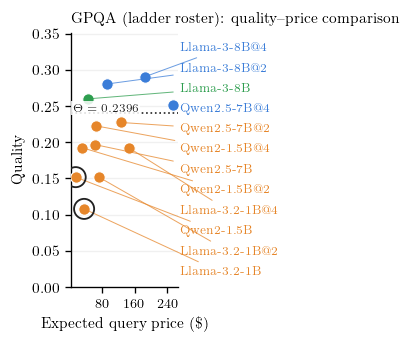

legend: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/legend_landscape.pdf


In [5]:
# Figure: quality against expected query price, one point per provider. The legend is a separate PDF.
fig, ax = plt.subplots(figsize=(3.4, 2.8))
ordered = sorted(MODELS, key=lambda m: TRUTH.q[m])
label_y = np.linspace(0.06, 0.94, len(ordered))
for rank, model in enumerate(ordered):
    color = COLOR_ISTAR if model == TRUTH.istar else COLOR_QUALIFIED if model in TRUTH.qualified else COLOR_UNQUALIFIED
    ax.scatter(TRUTH.price[model], TRUTH.q[model], s=48, color=color, edgecolor="white", linewidth=0.7, zorder=3)
    ax.annotate(
        model, (TRUTH.price[model], TRUTH.q[model]), xytext=(1.02, label_y[rank]), textcoords=ax.transAxes,
        color=color, va="center", fontsize=7.2, zorder=4, clip_on=False,
        arrowprops={"arrowstyle": "-", "color": color, "lw": 0.6, "alpha": 0.75},
    )
    if model in LOWEST_PRICE:
        ax.scatter(TRUTH.price[model], TRUTH.q[model], s=145, facecolor="none", edgecolor="#222", linewidth=1.1, zorder=5)
hline(ax, ENV.theta, f"$\\Theta = {ENV.theta}$", style=":")
ax.set_ylim(0, min(1.0, 1.14 * max(TRUTH.q.values()) + 0.02))
ax.xaxis.set_major_locator(plt.MaxNLocator(4))
ax.tick_params(axis="x", labelsize=8)
ax.set_xlabel("Expected query price (\\$)")
ax.set_ylabel("Quality")
finish(fig, "quality_vs_query_price", title=f"{BENCHMARK} ({ROSTER} roster): quality–price comparison", legend=False, rect=(0, 0, 0.74, 1))

save_legend([
    (Line2D([], [], linestyle="none", marker="o", color=COLOR_ISTAR, markersize=7), "$i^*$"),
    (Line2D([], [], linestyle="none", marker="o", color=COLOR_QUALIFIED, markersize=7), "Other qualified provider"),
    (Line2D([], [], linestyle="none", marker="o", color=COLOR_UNQUALIFIED, markersize=7), "Unqualified provider"),
    (Line2D([], [], linestyle="none", marker="o", markerfacecolor="none", markeredgecolor="#222", markersize=10), "Lowest listed price"),
], "landscape", ncol=4)

## 2. One pass

`REPS` paired repetitions of one pass over the benchmark: within a repetition every policy sees
the same question order, initialization order, tie draws and outcomes.

Policies: the mechanism (bids, graded outcomes, quality filter; pays the critical payment),
uniform among eligible, lowest listed price among eligible, lowest listed price without a
filter, and the no-quality-filter ablation (the mechanism's score and payment without the
filter). The listed-price policies pay the query price.

In [6]:
# The policies, the information each one uses, and what it pays.
header = ["policy", "label", "role", "information used", "amount paid"]
rows = [
    ["mechanism", STYLE["mechanism"]["label"], ROLE["mechanism"],
     "graded outcomes, standing bids, Theta, confidence radii, C_max" + (f"; {EXPLORATION_TEXT}" if EXPLORING else ""),
     "critical payment" + ("; forced rounds paid C_max" if EXPLORING else "")],
    ["uniform_eligible", STYLE["uniform_eligible"]["label"], ROLE["uniform_eligible"],
     "graded outcomes and the online quality filter", "query price"],
    ["cheapest_rate_eligible", STYLE["cheapest_rate_eligible"]["label"], ROLE["cheapest_rate_eligible"],
     "graded outcomes, the online quality filter and listed prices", "query price"],
    ["cheapest_price", STYLE["cheapest_price"]["label"], ROLE["cheapest_price"],
     "listed prices only", "query price"],
    ["no_quality_filter", STYLE["no_quality_filter"]["label"], ROLE["no_quality_filter"],
     "standing bids, Theta, confidence radii, C_max; no quality filter", "critical payment"],
]
show(header, rows)
save_table(header, rows, "policies")

                policy                                   label       role                                                                                                                                                                                   information used                                 amount paid
             mechanism                                Platform  mechanism  graded outcomes, standing bids, Theta, confidence radii, C_max; a forced round, paid C_max, for an under-sampled eligible provider whenever one has fewer than ceil(2 (t / n)^(3/4)) observations  critical payment; forced rounds paid C_max
      uniform_eligible                  Uniform among eligible   baseline                                                                                                                                                      graded outcomes and the online quality filter                                 query price
cheapest_rate_eligible      Lowest listed price among eligibl

In [7]:
# Run the paired one-pass experiment: REPS repetitions x POLICIES. One record per episode.
def episode_record(name, rep, seed, arm, episode):
    metrics = evaluate(episode.log, TRUTH, arm.radii, variant=arm.exploration)
    post = evaluate(window(episode.log, start=N + 1), TRUTH, arm.radii)   # after initialization
    columns = episode.log.columns()
    main = columns["phase"] == "main"
    paid = metrics.total_payment is not None
    # The forced rounds are rounds of the log, so `metrics` counts them; `explored` totals them.
    explored = exploration_metrics(exploration_events(episode), TRUTH) if arm.exploration is not None else None
    amount_paid = metrics.total_payment if paid else metrics.total_invoice
    amount_paid_post = post.total_payment if paid else post.total_invoice
    payoff = metrics.provider_payoff

    # Payment bounds of the payment-bounds lemma, checked round by round.
    rho = np.array([arm.radii.rho(int(m)) for m in columns["m_winner"][main]])
    winner_cost = np.array([TRUTH.c[m] for m in columns["winner"][main]])
    lower = np.maximum(0.0, winner_cost - rho)
    upper = np.minimum(arm.radii.c_max, TRUTH.c_second + rho)
    payment = columns["payment"][main].astype(float)
    bound_violations = int(np.sum((payment < lower - 1e-9) | (payment > upper + 1e-9))) if paid else None

    assert np.isclose(metrics.total_invoice, (1 + MARGIN) * metrics.total_cost)
    record = {
        "environment": ENV.id,
        "policy": name,
        "role": ROLE[name],
        "repetition": rep,
        "seed": seed,
        "rounds": metrics.rounds,
        "termination": episode.termination,
        "amount_paid_basis": ("critical payment" if paid else "query price") + (EXPLORATION_BASIS if explored is not None else ""),
        "unqualified_share": metrics.unqualified_rounds / metrics.rounds,
        "unqualified_share_post_init": post.unqualified_rounds / post.rounds,
        "quality_regret_per_round": metrics.quality_regret / metrics.rounds,
        "generation_regret_per_round": metrics.generation_regret / metrics.rounds,
        "realized_accuracy": metrics.realized_accuracy,
        "istar_share": metrics.istar_share,
        "generation_cost_per_query": metrics.total_cost / metrics.rounds,
        "generation_cost_per_query_post_init": post.total_cost / post.rounds,
        "query_price_per_query": metrics.total_invoice / metrics.rounds,
        "query_price_per_query_post_init": post.total_invoice / post.rounds,
        "mean_winning_bid_post_init": float(np.nanmean(columns["bid_winner"][main].astype(float))),
        "mechanism_payment_per_query": metrics.total_payment / metrics.rounds if paid else None,
        "mechanism_payment_per_query_post_init": post.total_payment / post.rounds if paid else None,
        # Ordinary rounds only: forced rounds pay C_max and are in the amount paid, not the critical payment.
        "critical_payment_per_query_main": float(payment.mean()) if paid else None,
        "excess_payment_per_round_main": float(np.maximum(payment - TRUTH.c_second, 0.0).mean()) if paid else None,
        "amount_paid_per_query": amount_paid / metrics.rounds,
        "amount_paid_per_query_post_init": amount_paid_post / post.rounds,
        "excess_payment_per_round": metrics.excess_payment / metrics.rounds if paid else None,
        "excess_payment_per_round_post_init": post.excess_payment / post.rounds if paid else None,
        "mean_provider_payoff": float(np.mean(list(payoff.values()))) if paid else None,
        "min_provider_payoff": min(payoff.values()) if paid else None,
        "critical_below_bid_rounds": metrics.critical_below_bid_rounds,
        "payment_bound_violations": bound_violations,
        "good_event_holds": metrics.good_event_holds,
        "good_event_violations": metrics.good_event_violations,
        "selection_counts": metrics.selection_counts,
        "provider_payoff": payoff,
    }
    if EXPLORING:   # None for the policies that do not explore
        record.update({
            "exploration_rounds": explored.rounds if explored else None,
            "exploration_share": explored.rounds / (metrics.rounds - N) if explored else None,
            "exploration_cost_per_query": explored.total_cost / metrics.rounds if explored else None,
            "exploration_payment_per_query": explored.total_payment / metrics.rounds if explored else None,
            "exploration_istar_rounds": explored.istar_rounds if explored else None,
            "exploration_unqualified_rounds": explored.unqualified_rounds if explored else None,
            "exploration_counts": explored.counts if explored else None,
        })
    return record


ONE = []
for rep in range(REPS):
    seed, dseed = episode_seed(MASTER, ENV.id, rep), draw_seed(MASTER, ENV.id)
    for name in POLICIES:
        arm = resolve_arm(ARM.get(name, name), CONFIG, TRUTH, RADII)
        episode = simulate_episode(
            DATA, MODELS, theta=ENV.theta, radii=arm.radii, estimator=arm.estimator, margin=MARGIN,
            t_max=ONE_PASS, seed=seed, draw_seed=dseed, repetition=rep,
            policy=make_policy(arm.policy_name, TRUTH), payment_rule=make_payment_rule(arm.payment_name),
            exploration=arm.exploration,
        )
        ONE.append(episode_record(name, rep, seed, arm, episode))
print(f"{ENV.id}: {REPS} repetitions x {len(POLICIES)} policies done")
save_records(ONE, "one_pass_per_repetition")


def pick(records, policy, key):
    return np.array([r[key] for r in records if r["policy"] == policy], dtype=float)

GPQA-ladder: 30 repetitions x 5 policies done
results: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/one_pass_per_repetition.csv


In [8]:
# Table: one-pass outcomes per policy, mean, standard deviation and 95% half-width over repetitions.
OUTCOME_METRICS = [
    "unqualified_share", "quality_regret_per_round", "generation_regret_per_round", "realized_accuracy",
    "istar_share", "generation_cost_per_query", "query_price_per_query", "amount_paid_per_query",
]
header = ["policy", "role", "amount paid basis"]
for key in OUTCOME_METRICS:
    header += [f"{key} mean", f"{key} sd", f"{key} 95% half-width"]
rows = []
for name in POLICIES:
    basis = next(r["amount_paid_basis"] for r in ONE if r["policy"] == name)
    row = [name, ROLE[name], basis]
    for key in OUTCOME_METRICS:
        values = pick(ONE, name, key)
        mean, half = mean_ci(values)
        row += [mean, sd(values), half]
    rows.append(row)
show(["policy", *OUTCOME_METRICS], [[row[0], *row[3::3]] for row in rows])
save_table(header, rows, "one_pass_outcomes")

                policy  unqualified_share  quality_regret_per_round  generation_regret_per_round  realized_accuracy  istar_share  generation_cost_per_query  query_price_per_query  amount_paid_per_query
             mechanism             0.7150                    0.0472                      32.9631             0.2007       0.0924                    64.4240                80.5300               196.5273
      uniform_eligible             0.6643                    0.0395                      42.1050             0.2113       0.0869                    75.8979                94.8723                94.8723
cheapest_rate_eligible             0.9927                    0.1081                       0.9353             0.1297       0.0018                    22.3316                27.9144                27.9144
        cheapest_price             0.9927                    0.1081                       0.9353             0.1297       0.0018                    22.3316                27.9144              

In [9]:
# Table: mechanism minus each other policy, paired within repetitions, with 95% half-widths.
COMPARE_METRICS = [
    "unqualified_share", "quality_regret_per_round", "generation_regret_per_round",
    "generation_cost_per_query", "amount_paid_per_query", "istar_share",
]
header = ["baseline", "role", *[f"{key} difference" for key in COMPARE_METRICS], *[f"{key} 95% half-width" for key in COMPARE_METRICS]]
rows = []
for name in POLICIES[1:]:
    stats = [mean_ci(pick(ONE, "mechanism", key) - pick(ONE, name, key)) for key in COMPARE_METRICS]
    rows.append([name, ROLE[name], *[s[0] for s in stats], *[s[1] for s in stats]])
show(["baseline", *COMPARE_METRICS], [row[:1] + row[2:2 + len(COMPARE_METRICS)] for row in rows])
save_table(header, rows, "one_pass_paired_differences")

              baseline  unqualified_share  quality_regret_per_round  generation_regret_per_round  generation_cost_per_query  amount_paid_per_query  istar_share
      uniform_eligible             0.0507                    0.0077                      -9.1419                   -11.4739               101.6550       0.0055
cheapest_rate_eligible            -0.2777                   -0.0609                      32.0278                    42.0924               168.6129       0.0905
        cheapest_price            -0.2777                   -0.0609                      32.0278                    42.0924               168.6129       0.0905
     no_quality_filter            -0.0791                   -0.0085                      17.0267                    19.0562               145.5072      -0.0206
table: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/one_pass_paired_differences.csv


figure: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/one_pass_quality_regret_vs_generation_cost.pdf


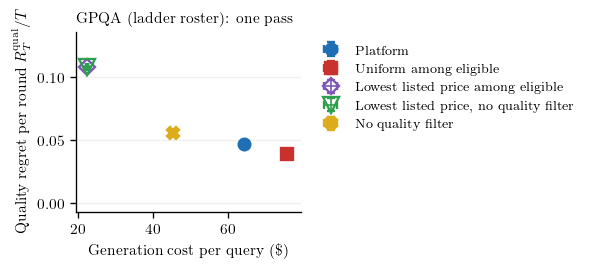

legend: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/legend_policies_markers.pdf


In [10]:
# Figure: quality regret per round against generation cost per query, every routing rule.
MARKER_SIZE = {"mechanism": 7, "uniform_eligible": 7, "cheapest_rate_eligible": 7, "cheapest_price": 10, "no_quality_filter": 7}


def one_pass_point(ax, name, x_key, y_key):
    style = STYLE[name]
    x, xerr = mean_ci(pick(ONE, name, x_key))
    y, yerr = mean_ci(pick(ONE, name, y_key))
    ax.errorbar(
        x, y, xerr=xerr, yerr=yerr, fmt=style["marker"], color=style["color"],
        markerfacecolor="none" if name in HOLLOW else style["color"], markeredgewidth=1.4,
        markersize=MARKER_SIZE[name], capsize=2.5, elinewidth=1, label=style["label"], zorder=4,
    )
    return y + yerr


fig, ax = plt.subplots(figsize=PANEL)
top = max(one_pass_point(ax, name, "generation_cost_per_query", "quality_regret_per_round") for name in POLICIES)
ax.set_xlabel("Generation cost per query (\\$)")
ax.set_ylabel("Quality regret per round $R_T^{\\mathrm{qual}}/T$")
ax.set_ylim(-0.06 * top, 1.25 * top)
finish(fig, "one_pass_quality_regret_vs_generation_cost", title=f"{BENCHMARK} ({ROSTER} roster): one pass")

save_legend([(policy_marker(name), STYLE[name]["label"]) for name in POLICIES], "policies_markers", ncol=2)

figure: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/one_pass_quality_vs_amount_paid.pdf


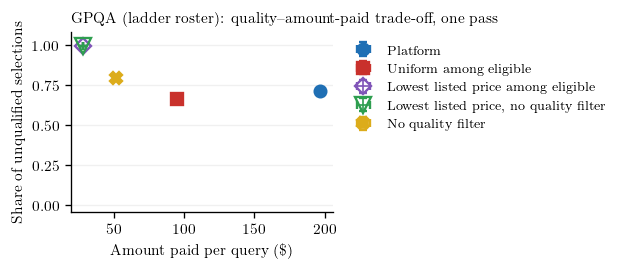

In [11]:
# Figure: share of unqualified selections against the amount paid per query, every routing rule.
fig, ax = plt.subplots(figsize=PANEL)
for name in POLICIES:
    one_pass_point(ax, name, "amount_paid_per_query", "unqualified_share")
ax.set_xlabel("Amount paid per query (\\$)")
ax.set_ylabel("Share of unqualified selections")
ax.set_ylim(-0.04, 1.08)
finish(fig, "one_pass_quality_vs_amount_paid", title=f"{BENCHMARK} ({ROSTER} roster): quality–amount-paid trade-off, one pass")

figure: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/one_pass_mechanism_selection_shares.pdf


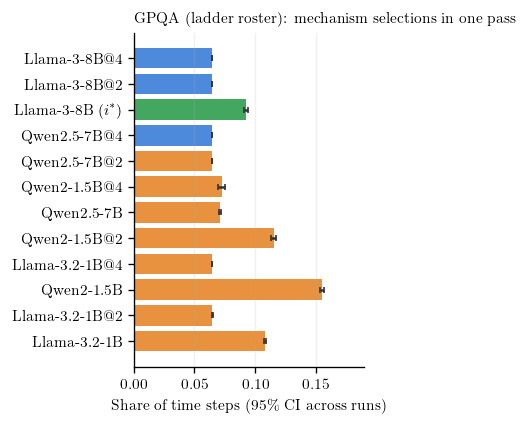

In [12]:
# Figure: where the mechanism's one-pass rounds went, per provider. Colour marks the true
# qualification (green i*, blue qualified, orange unqualified); the mechanism never sees it.
ordered = sorted(MODELS, key=lambda m: TRUTH.q[m])
means, halves = [], []
for model in ordered:
    shares = [r["selection_counts"][model] / r["rounds"] for r in ONE if r["policy"] == "mechanism"]
    mean, half = mean_ci(shares)
    means.append(mean)
    halves.append(half)
colors = [COLOR_ISTAR if m == TRUTH.istar else COLOR_QUALIFIED if m in TRUTH.qualified else COLOR_UNQUALIFIED for m in ordered]
labels = [m + ("  ($i^*$)" if m == TRUTH.istar else "") for m in ordered]

fig, ax = plt.subplots(figsize=(PANEL[0], 0.22 * N + 0.8))
y = np.arange(N)
ax.barh(y, means, xerr=halves, color=colors, alpha=0.9, ecolor="#333", capsize=2)
ax.set_yticks(y, labels)
ax.set_xlabel(f"Share of time steps (95{PCT} CI across runs)")
ax.set_xlim(0, max(means) * 1.22)
ax.grid(axis="x", alpha=0.18)
ax.grid(axis="y", visible=False)
finish(fig, "one_pass_mechanism_selection_shares", title=f"{BENCHMARK} ({ROSTER} roster): mechanism selections in one pass", legend=False)

## 3. Long horizon

`T_LONG` rounds. After the first pass the questions are reshuffled and the generations redrawn
from the recorded pools. Trajectories are the median over repetitions with a 10–90% band;
"rolling" is a window of one pass. Identification is the fraction of repetitions in which $i^*$
is the unique selection leader.

In [13]:
# Checkpoints, the evaluation grid and the rolling window.
CHECKPOINTS = sorted({N, ONE_PASS, 5_000, 10_000, 25_000, 50_000, TC.need + 1, T_LONG} & set(range(1, T_LONG + 1)))
GRID = np.unique(np.concatenate([np.round(np.logspace(np.log10(N), np.log10(T_LONG), 160)).astype(int), CHECKPOINTS]))
GRID_INDEX = GRID - 1
INDEX = {model: j for j, model in enumerate(MODELS)}
ISTAR = INDEX[TRUTH.istar]
QUALIFIED = np.array([INDEX[m] for m in TRUTH.qualified])
Q_VEC = np.array([TRUTH.q[m] for m in MODELS])
C_VEC = np.array([TRUTH.c[m] for m in MODELS])
RATE_VEC = np.array([public_invoice(m, 1) for m in MODELS])   # listed price per token


def rolling(cumulative, valid=None):
    # Mean over the last pass; over all rounds so far before one pass is complete. `valid` is the
    # cumulative count of rounds that enter the mean; by default every round does.
    if valid is None:
        valid = np.arange(1, len(cumulative) + 1)
    complete = GRID_INDEX >= ONE_PASS
    start = np.maximum(GRID_INDEX - ONE_PASS, 0)
    total = cumulative[GRID_INDEX] - np.where(complete, cumulative[start], 0.0)
    count = valid[GRID_INDEX] - np.where(complete, valid[start], 0)
    return np.divide(total, count, out=np.full(len(GRID), np.nan), where=count > 0)


AFTER_INIT = np.arange(T_LONG) >= N   # initialization pays C_max, so payment quantities exclude it


def rolling_after_init(values):
    return rolling(np.cumsum(np.where(AFTER_INIT, values, 0.0)), np.cumsum(AFTER_INIT))


def rolling_main(values):
    # Over the ordinary rounds only (`main` of the episode at hand).
    return rolling(np.cumsum(np.where(main, values, 0.0)), np.cumsum(main))


print(f"{ENV.id}: {T_LONG:,} rounds = {-(-T_LONG // ONE_PASS)} passes; "
      f"identification horizon {'T_id' if EXPLORING else 'n + 2 B_id'} = {TC.need + 1 if EXPLORING else TC.need:,}; within T_LONG: {TC.reachable}")
print("checkpoints:", CHECKPOINTS)

GPQA-ladder: 70,000 rounds = 129 passes; identification horizon T_id = 2,540,927; within T_LONG: False
checkpoints: [12, 545, 5000, 10000, 25000, 50000, 70000]


In [14]:
# Run the long-horizon episodes and keep every trajectory on the grid.
LONG = {name: [] for name in LONG_POLICIES}
for rep in range(LONG_REPS):
    seed, dseed = episode_seed(MASTER, ENV.id, rep), draw_seed(MASTER, ENV.id)
    for name in LONG_POLICIES:
        arm = resolve_arm(ARM.get(name, name), CONFIG, TRUTH, RADII)
        episode = simulate_episode(
            DATA, MODELS, theta=ENV.theta, radii=arm.radii, estimator=arm.estimator, margin=MARGIN,
            t_max=T_LONG, seed=seed, draw_seed=dseed, repetition=rep, resample=True,
            policy=make_policy(arm.policy_name, TRUTH), payment_rule=make_payment_rule(arm.payment_name),
            exploration=arm.exploration,
        )
        if episode.rounds != T_LONG:
            raise RuntimeError(f"{name}, repetition {rep} halted at {episode.rounds}")
        columns = episode.log.columns()
        main = columns["phase"] == "main"   # ordinary mechanism rounds: after initialization, forced rounds excluded
        forced = columns["phase"] == "explore"   # the forced rounds of the count mode, paid C_max
        winners = np.fromiter((INDEX[m] for m in columns["winner"]), dtype=int, count=T_LONG)
        rounds = np.arange(1, T_LONG + 1)
        counts = np.stack([np.cumsum(winners == j) for j in range(N)], axis=1)
        cum_istar = counts[:, ISTAR]
        cum_unqualified = rounds - counts[:, QUALIFIED].sum(axis=1)
        cum_quality_regret = np.cumsum(np.maximum(ENV.theta - Q_VEC[winners], 0.0))
        cum_generation_regret = np.cumsum(np.maximum(C_VEC[winners] - TRUTH.c_star, 0.0))
        cum_cost = np.cumsum(columns["cost"])
        cum_price = np.cumsum(columns["num_tokens"].astype(float) * RATE_VEC[winners])
        payment = columns["payment"].astype(float)
        paid = not np.isnan(payment).any()
        amount = payment if paid else columns["num_tokens"].astype(float) * RATE_VEC[winners]
        # The forced rounds, per round (zero where none); their C_max payments are in `payment` already.
        exploration_payment, exploration_cost, explored_round = np.zeros(T_LONG), np.zeros(T_LONG), np.zeros(T_LONG)
        exploration_counts = np.zeros(N, dtype=int)
        if arm.exploration is not None:
            x = exploration_events(episode).columns()
            if len(x["t"]):
                exploration_payment[x["t"] - 1] = x["payment"]
                exploration_cost[x["t"] - 1] = x["cost"]
                explored_round[x["t"] - 1] = 1.0
                exploration_counts = np.array([int((x["explored"] == m).sum()) for m in MODELS])
        cum_paid = np.cumsum(amount)
        bid = np.nan_to_num(columns["bid_winner"].astype(float))   # NaN in the initialization rounds
        at_grid = counts[GRID_INDEX]
        leader = at_grid.max(axis=1)
        audit = evaluate(episode.log, TRUTH, arm.radii, variant=arm.exploration) if paid else None
        payoff = audit.provider_payoff if audit else None
        if paid:   # the payment bounds of the payment-bounds lemma, round by round, kept on the grid
            rho = np.array([arm.radii.rho(int(m)) if m > 0 else np.nan for m in columns["m_winner"]])
            # On the ordinary mechanism rounds only: a forced round pays C_max, not the critical payment.
            bound_lower = np.where(main, np.maximum(0.0, C_VEC[winners] - rho), np.nan)[GRID_INDEX]
            bound_upper = np.where(main, np.minimum(arm.radii.c_max, TRUTH.c_second + rho), np.nan)[GRID_INDEX]
        LONG[name].append({
            "repetition": rep,
            "seed": seed,
            "amount_paid_basis": ("critical payment" if paid else "query price") + (EXPLORATION_BASIS if arm.exploration is not None else ""),
            "istar_share": cum_istar[GRID_INDEX] / GRID,
            "rolling_istar_share": rolling(cum_istar),
            "unqualified_share": cum_unqualified[GRID_INDEX] / GRID,
            "rolling_unqualified_share": rolling(cum_unqualified),
            "quality_regret": cum_quality_regret[GRID_INDEX],
            "generation_regret": cum_generation_regret[GRID_INDEX],
            "generation_cost_per_query": cum_cost[GRID_INDEX] / GRID,
            "rolling_generation_cost": rolling(cum_cost),
            "rolling_generation_cost_after_init": rolling_after_init(columns["cost"]),
            "query_price_per_query": cum_price[GRID_INDEX] / GRID,
            "rolling_query_price_after_init": rolling_after_init(columns["num_tokens"].astype(float) * RATE_VEC[winners]),
            "rolling_winning_bid": rolling_main(bid),
            "amount_paid_per_query": cum_paid[GRID_INDEX] / GRID,
            "rolling_amount_paid": rolling_after_init(amount),
            "excess_payment": np.cumsum(np.maximum(payment - TRUTH.c_second, 0.0))[GRID_INDEX] if paid else None,
            "excess_payment_main": np.cumsum(np.where(~forced, np.maximum(payment - TRUTH.c_second, 0.0), 0.0))[GRID_INDEX] if paid else None,   # forced rounds excluded
            "rolling_mechanism_payment": rolling_main(payment) if paid else None,   # the critical payment on ordinary rounds
            "leader_is_istar": (at_grid[:, ISTAR] == leader) & ((at_grid == leader[:, None]).sum(axis=1) == 1),
            "n_eligible": columns["n_eligible"][GRID_INDEX].astype(float),
            "final_counts": counts[-1],
            "last_selection_round": np.array([rounds[winners == j].max() for j in range(N)]),
            "realized_accuracy": float(columns["correctness"].mean()),
            "good_event_holds": audit.good_event_holds if audit else None,
            "good_event_violations": audit.good_event_violations if audit else None,
            "critical_below_bid_rounds": audit.critical_below_bid_rounds if audit else None,
            "provider_payoff": payoff,
            "payment_at_grid": np.where(main, payment, np.nan)[GRID_INDEX] if paid else None,   # ordinary rounds only
            "bound_lower": bound_lower if paid else None,
            "bound_upper": bound_upper if paid else None,
            **({   # zero for the policies that do not explore
                "rolling_exploration_share": rolling_after_init(explored_round),
                "rolling_exploration_payment": rolling_after_init(exploration_payment),
                "rolling_exploration_cost": rolling_after_init(exploration_cost),
                "exploration_rounds": int(explored_round.sum()),
                "exploration_counts": exploration_counts,
            } if EXPLORING else {}),
        })
    print(f"long-horizon repetition {rep + 1}/{LONG_REPS} done")

long-horizon repetition 1/30 done


long-horizon repetition 2/30 done


long-horizon repetition 3/30 done


long-horizon repetition 4/30 done


long-horizon repetition 5/30 done


...

long-horizon repetition 26/30 done


long-horizon repetition 27/30 done


long-horizon repetition 28/30 done


long-horizon repetition 29/30 done


long-horizon repetition 30/30 done


In [15]:
# Save every repetition's grid trajectories and final selection counts.
GRID_KEYS = [
    "istar_share", "rolling_istar_share", "unqualified_share", "rolling_unqualified_share", "quality_regret",
    "generation_regret", "generation_cost_per_query", "rolling_generation_cost", "rolling_generation_cost_after_init",
    "query_price_per_query", "rolling_query_price_after_init", "rolling_winning_bid", "amount_paid_per_query", "rolling_amount_paid",
    "excess_payment", "rolling_mechanism_payment", "leader_is_istar", "n_eligible",
    "payment_at_grid", "bound_lower", "bound_upper",
]
if EXPLORING:
    GRID_KEYS += ["rolling_exploration_share", "rolling_exploration_payment", "rolling_exploration_cost", "excess_payment_main"]
grid_records, count_records = [], []
for name in LONG_POLICIES:
    for record in LONG[name]:
        for k, t in enumerate(GRID):
            row = {"environment": ENV.id, "policy": name, "repetition": record["repetition"], "seed": record["seed"],
                   "round": int(t), "amount_paid_basis": record["amount_paid_basis"]}
            for key in GRID_KEYS:
                row[key] = None if record[key] is None else _cell(record[key][k])
            grid_records.append(row)
        for model in MODELS:
            j = INDEX[model]
            count_records.append({
                "environment": ENV.id, "policy": name, "repetition": record["repetition"], "seed": record["seed"],
                "provider": model, "qualified": model in TRUTH.qualified, "is_i_star": model == TRUTH.istar,
                "final_selections": int(record["final_counts"][j]),
                "post_initialization_selections": int(record["final_counts"][j] - 1),
                "last_selection_round": int(record["last_selection_round"][j]),
                **({"exploration_events": int(record["exploration_counts"][j])} if EXPLORING else {}),
            })
save_records(grid_records, "long_horizon_grid_per_repetition")
save_records(count_records, "long_horizon_final_counts_per_repetition")

results: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/long_horizon_grid_per_repetition.csv
results: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/long_horizon_final_counts_per_repetition.csv


figure: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/long_horizon_rolling_i_star_share.pdf


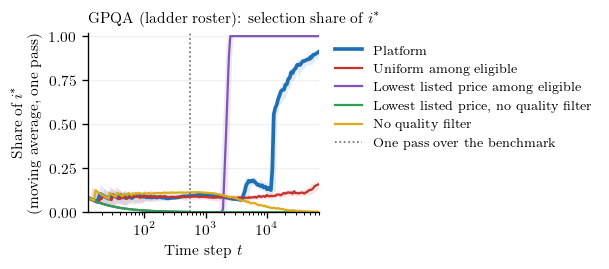

figure: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/long_horizon_i_star_identification_probability.pdf


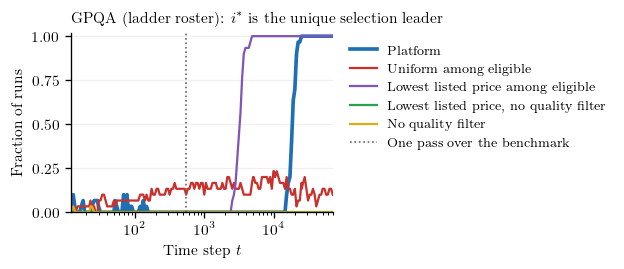

legend: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/legend_policies_lines.pdf


In [16]:
# Figures: rolling selection share of i*, and the probability that i* is the unique leader.
# Panels are saved without legends; `legend_policies_lines.pdf` is shared by every all-policy trajectory.
def long_band(ax, name, key, *, per_round=False):
    values = np.array([r[key] for r in LONG[name]], dtype=float)
    if per_round:
        values = values / GRID
    color, width = STYLE[name]["color"], 2.2 if name == "mechanism" else 1.35
    ax.plot(GRID, np.median(values, axis=0), color=color, linewidth=width, label=STYLE[name]["label"])
    ax.fill_between(GRID, np.percentile(values, 10, axis=0), np.percentile(values, 90, axis=0), color=color, alpha=0.13, linewidth=0)


def long_marks(ax):
    ax.axvline(ONE_PASS, color="#666", linestyle=":", linewidth=1, label="One pass over the benchmark")
    if TC.reachable:
        ax.axvline(HORIZON_MARK, color="#888", linestyle="--", linewidth=1, label=VLINES[1][1])
    ax.set_xscale("log")
    ax.set_xlim(N, T_LONG)
    ax.set_xlabel("Time step $t$")


def long_figure(key, ylabel, title, name, *, per_round=False, log_y=False, ylim=None, policies=LONG_POLICIES, lines=()):
    fig, ax = plt.subplots(figsize=PANEL)
    for policy in policies:
        long_band(ax, policy, key, per_round=per_round)
    long_marks(ax)
    for value, label, above in lines:
        hline(ax, value, label, style=":", above=above)
    if log_y:
        ax.set_yscale("log")
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel)
    finish(fig, name, title=title)


long_figure("rolling_istar_share", "Share of $i^*$\n(moving average, one pass)",
            f"{BENCHMARK} ({ROSTER} roster): selection share of $i^*$", "long_horizon_rolling_i_star_share", ylim=(0, 1.02))

fig, ax = plt.subplots(figsize=PANEL)
for name in LONG_POLICIES:
    probability = np.mean([r["leader_is_istar"] for r in LONG[name]], axis=0)
    ax.plot(GRID, probability, color=STYLE[name]["color"], linewidth=2.2 if name == "mechanism" else 1.35, label=STYLE[name]["label"])
long_marks(ax)
ax.set_ylim(0, 1.02)
ax.set_ylabel("Fraction of runs")
finish(fig, "long_horizon_i_star_identification_probability", title=f"{BENCHMARK} ({ROSTER} roster): $i^*$ is the unique selection leader")

save_legend([(policy_line(name), STYLE[name]["label"]) for name in LONG_POLICIES] + VLINES[:1 + bool(TC.reachable)],
            "policies_lines", ncol=2)

figure: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/long_horizon_eligible_providers.pdf


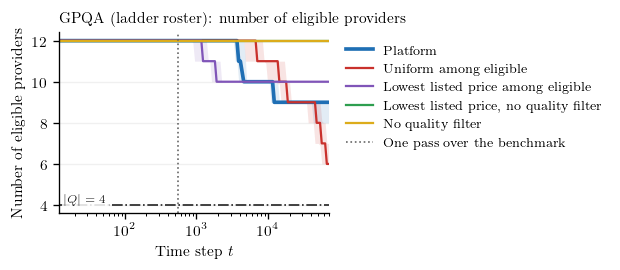

figure: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/long_horizon_unqualified_share.pdf


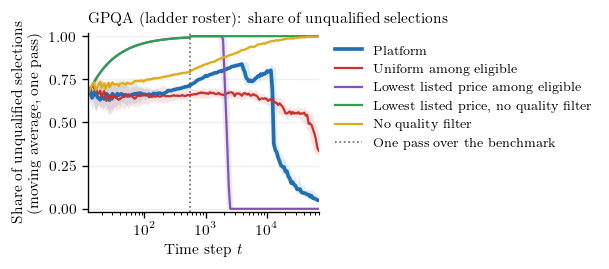

figure: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/long_horizon_generation_cost_per_query.pdf


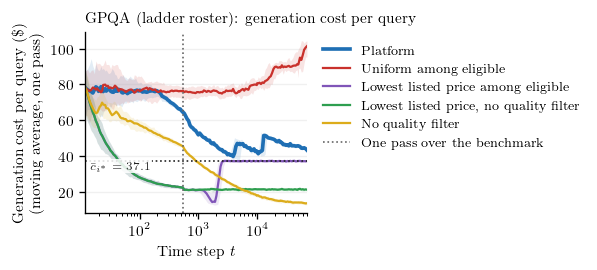

In [17]:
# Figures: eligible providers, unqualified share and generation cost per query of every rule.
fig, ax = plt.subplots(figsize=PANEL)
for name in LONG_POLICIES:
    long_band(ax, name, "n_eligible")
long_marks(ax)
hline(ax, len(TRUTH.qualified), f"$|Q| = {len(TRUTH.qualified)}$", style="-.")
ax.set_ylabel("Number of eligible providers")
finish(fig, "long_horizon_eligible_providers", title=f"{BENCHMARK} ({ROSTER} roster): number of eligible providers")

long_figure("rolling_unqualified_share", "Share of unqualified selections\n(moving average, one pass)",
            f"{BENCHMARK} ({ROSTER} roster): share of unqualified selections", "long_horizon_unqualified_share", ylim=(-0.02, 1.02))

lines = [(TRUTH.c_star, f"$\\bar c_{{i^*}} = {TRUTH.c_star:.1f}$", False)]
if LOWEST_PRICE_QUALIFIED != TRUTH.istar:
    lines.append((TRUTH.c[LOWEST_PRICE_QUALIFIED], f"cheapest listed qualified: {TRUTH.c[LOWEST_PRICE_QUALIFIED]:.1f}", True))
long_figure("rolling_generation_cost", "Generation cost per query (\\$)\n(moving average, one pass)",
            f"{BENCHMARK} ({ROSTER} roster): generation cost per query", "long_horizon_generation_cost_per_query", lines=lines)

In [18]:
# Table: means over repetitions at the checkpoints. Regrets are per round; the leader column is
# the fraction of repetitions in which i* is the unique selection leader.
at = {int(t): int(np.flatnonzero(GRID == t)[0]) for t in CHECKPOINTS}
CHECKPOINT_KEYS = [
    "istar_share", "rolling_istar_share", "unqualified_share", "quality_regret_per_round", "generation_regret_per_round",
    "generation_cost_per_query", "query_price_per_query", "amount_paid_per_query", "excess_payment_per_round",
    "leader_is_istar", "n_eligible",
]
if EXPLORING:
    CHECKPOINT_KEYS += ["rolling_exploration_share", "rolling_exploration_payment", "excess_payment_main_per_round"]


def checkpoint_value(record, key, k):
    if key.endswith("_per_round"):
        base = record.get(key.removesuffix("_per_round"))
        return None if base is None else base[k] / GRID[k]
    value = record.get(key)
    return None if value is None else value[k]


header = ["policy", "role", "amount paid basis", "round", *CHECKPOINT_KEYS]
rows = []
for name in LONG_POLICIES:
    for t in CHECKPOINTS:
        values = []
        for key in CHECKPOINT_KEYS:
            available = [checkpoint_value(r, key, at[t]) for r in LONG[name]]
            available = [v for v in available if v is not None]
            values.append(float(np.mean(available)) if available else "")
        rows.append([name, ROLE[name], LONG[name][0]["amount_paid_basis"], t, *values])
show(["policy", "round", *CHECKPOINT_KEYS], [[row[0], *row[3:]] for row in rows])
save_table(header, rows, "long_horizon_checkpoints")

                policy  round  istar_share  rolling_istar_share  unqualified_share  quality_regret_per_round  generation_regret_per_round  generation_cost_per_query  query_price_per_query  amount_paid_per_query  excess_payment_per_round  leader_is_istar  n_eligible  rolling_exploration_share  rolling_exploration_payment  excess_payment_main_per_round
             mechanism     12       0.0833               0.0833             0.6667                    0.0396                      42.4788                    76.8817                96.1022               300.0320                  225.7930           0.0000     12.0000                        nan                          nan                       225.7930
             mechanism    545       0.0924               0.0924             0.7150                    0.0472                      32.9631                    64.4240                80.5300               196.5273                  140.1988           0.0000     12.0000                     0.6124  

## 4. Regret and bounds

Average regrets of every policy; the mechanism's cumulative regrets and excess payment against
their bounds, both branches (with forced exploration the generation bound and the total
excess-payment bound account for the forced rounds); selections of every provider other than
$i^*$ against its cap and the total against $B_{\mathrm{id}}(T)$.

figure: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/long_horizon_quality_regret_per_round.pdf


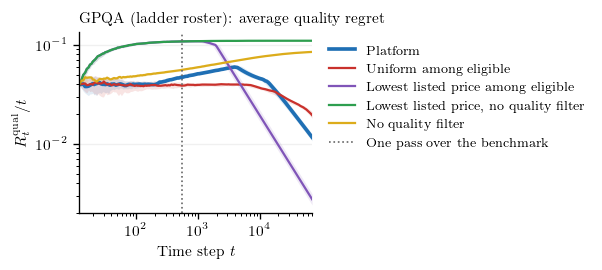

figure: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/long_horizon_generation_regret_per_round.pdf


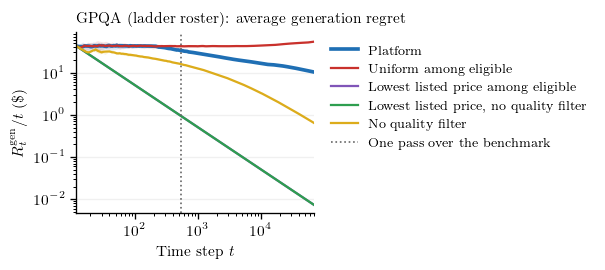

In [19]:
# Figures: average quality regret and average generation regret of every routing rule
# (cumulative regret divided by the round).
long_figure("quality_regret", "$R_t^{\\mathrm{qual}}/t$", f"{BENCHMARK} ({ROSTER} roster): average quality regret",
            "long_horizon_quality_regret_per_round", per_round=True, log_y=True)
long_figure("generation_regret", "$R_t^{\\mathrm{gen}}/t$ (\\$)", f"{BENCHMARK} ({ROSTER} roster): average generation regret",
            "long_horizon_generation_regret_per_round", per_round=True, log_y=True)

figure: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/long_horizon_quality_regret_vs_bound.pdf


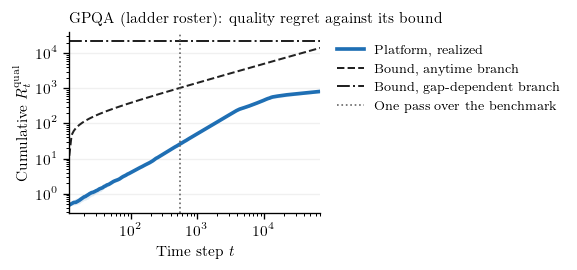

figure: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/long_horizon_generation_regret_vs_bound.pdf


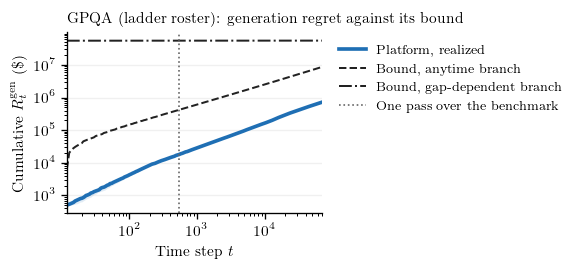

figure: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/long_horizon_excess_payment_vs_bound.pdf


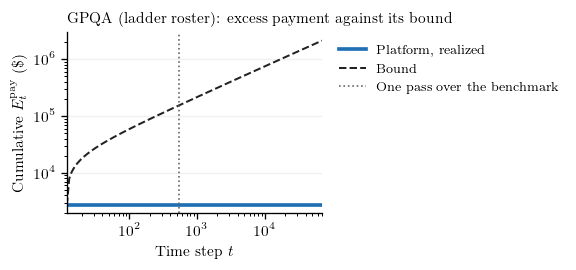

legend: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/legend_bounds.pdf
round  quality regret (mean)  quality bound (anytime)  quality bound (gap)  generation regret (mean)  generation bound (anytime)  generation bound (gap)  excess payment (mean)  payment bound (anytime)  excess payment, forced rounds excluded (mean)  payment bound incl. forced rounds (anytime)
   12                 0.4753                  12.0000           22811.0906                  509.7452                   6600.7040           54915806.8641              2709.5155                2709.5155                                      2709.5155                                    5419.0310
  545                25.7126                1022.7575           22811.0906                17964.9125                 418771.9235           54915806.8641             76408.3369              154339.3173                                      2709.5155                                  246462.8440
 5000               281.3149      

In [20]:
# Cumulative regrets against both branches of their bounds and the excess payment against its
# bound, evaluated on the grid; with forced exploration the bounds account for the forced rounds.
BOUND = {key: np.array([getattr(bounds(int(t), TRUTH, RADII, VARIANT), key) for t in GRID])
         for key in ("quality_anytime", "quality_gap", "generation_anytime", "generation_gap", "payment_anytime", "payment_anytime_forced")}
BOUND_STYLE = {"anytime": ("--", "Bound, anytime branch"), "gap": ("-.", "Bound, gap-dependent branch")}


def bound_figure(key, bound_prefix, ylabel, title, name, *, gap_branch=True):
    values = np.array([r[key] for r in LONG["mechanism"]], dtype=float)
    fig, ax = plt.subplots(figsize=PANEL)
    ax.plot(GRID, np.median(values, axis=0), color=STYLE["mechanism"]["color"], linewidth=2.2, label="Platform, realized")
    ax.fill_between(GRID, np.percentile(values, 10, axis=0), np.percentile(values, 90, axis=0),
                    color=STYLE["mechanism"]["color"], alpha=0.13, linewidth=0)
    for branch in ("anytime", "gap") if gap_branch else ("anytime",):
        style, label = BOUND_STYLE[branch]
        ax.plot(GRID, BOUND[f"{bound_prefix}_{branch}"], color="#222", linestyle=style, linewidth=1.2, label=label if gap_branch else "Bound")
    long_marks(ax)
    ax.set_yscale("log")
    ax.set_ylabel(ylabel)
    finish(fig, name, title=title)


bound_figure("quality_regret", "quality", "Cumulative $R_t^{\\mathrm{qual}}$",
             f"{BENCHMARK} ({ROSTER} roster): quality regret against its bound", "long_horizon_quality_regret_vs_bound")
bound_figure("generation_regret", "generation", "Cumulative $R_t^{\\mathrm{gen}}$ (\\$)",
             f"{BENCHMARK} ({ROSTER} roster): generation regret against its bound", "long_horizon_generation_regret_vs_bound")
# The panel shows the excess payment over ordinary rounds; the table also gives the total.
bound_figure("excess_payment_main" if EXPLORING else "excess_payment", "payment", "Cumulative $E_t^{\\mathrm{pay}}$ (\\$)",
             f"{BENCHMARK} ({ROSTER} roster): excess payment against its bound", "long_horizon_excess_payment_vs_bound", gap_branch=False)

save_legend([
    (Line2D([], [], color=STYLE["mechanism"]["color"], linewidth=2.2), "Platform, realized (median)"),
    (Patch(facecolor=STYLE["mechanism"]["color"], alpha=0.25, linewidth=0), f"10{DASH}90{PCT} band across runs"),
    (Line2D([], [], color="#222", linestyle="--", linewidth=1.2), "Bound, anytime branch"),
    (Line2D([], [], color="#222", linestyle="-.", linewidth=1.2), "Bound, gap-dependent branch"),
] + VLINES[:1 + bool(TC.reachable)], "bounds", ncol=2)

header = ["round", "quality regret (mean)", "quality bound (anytime)", "quality bound (gap)",
          "generation regret (mean)", "generation bound (anytime)", "generation bound (gap)",
          "excess payment (mean)", "payment bound (anytime)"] + (["excess payment, forced rounds excluded (mean)", "payment bound incl. forced rounds (anytime)"] if EXPLORING else [])
rows = []
for t in CHECKPOINTS:
    k = at[t]
    rows.append([
        t, float(np.mean([r["quality_regret"][k] for r in LONG["mechanism"]])), BOUND["quality_anytime"][k], BOUND["quality_gap"][k],
        float(np.mean([r["generation_regret"][k] for r in LONG["mechanism"]])), BOUND["generation_anytime"][k], BOUND["generation_gap"][k],
        float(np.mean([r["excess_payment"][k] for r in LONG["mechanism"]])), BOUND["payment_anytime"][k],
        *([float(np.mean([r["excess_payment_main"][k] for r in LONG["mechanism"]])), BOUND["payment_anytime_forced"][k]] if EXPLORING else []),
    ])
show(header, rows)
save_table(header, rows, "long_horizon_regret_bounds")

                   provider  qualified?              gap type       gap  mean selections after initialization  max selections after initialization  mean last selection round  bound (M or L)  mean / bound  bound incl. forced rounds  mean / bound incl. forced rounds
               Llama-3-8B@2        True  Delta_j = c_j - c_i*   37.1195                             1334.0000                            1334.0000                 69936.0333            4674        0.2854                       4674                            0.2854
               Llama-3-8B@4        True  Delta_j = c_j - c_i*  111.3586                             1334.0000                            1334.0000                 69935.8667             392        3.4031                       1334                            1.0000
               Llama-3.2-1B       False   eps_j = Theta - q_j    0.1318                              545.3000                             716.0000                  4314.2333            4063        0.1342  

figure: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/long_horizon_selections_vs_bounds.pdf


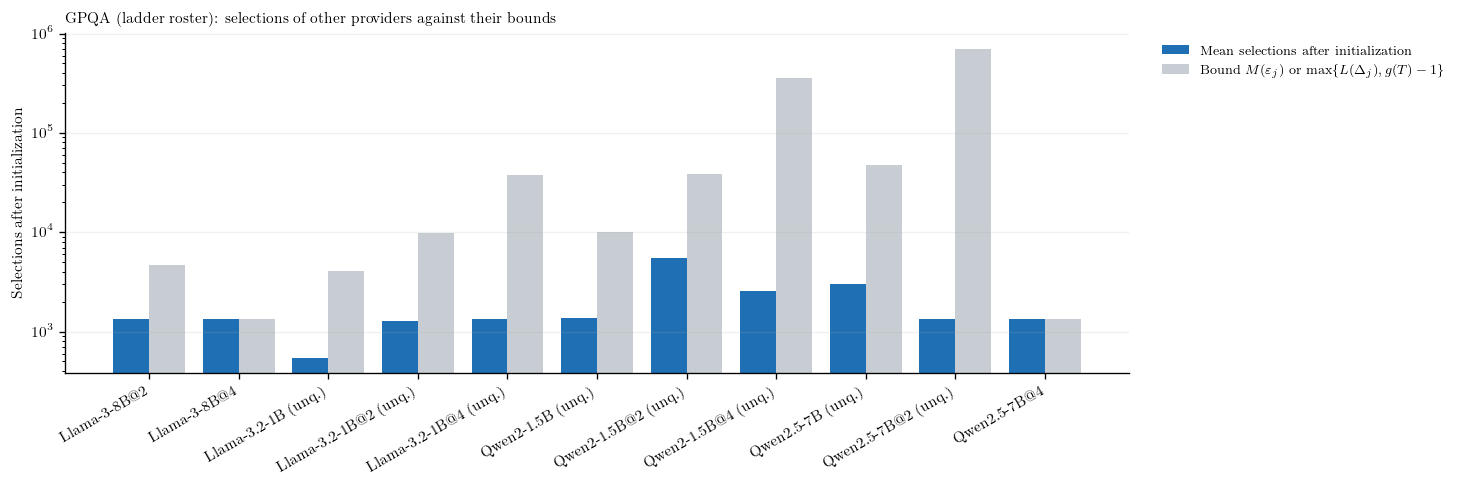

In [21]:
# Selections of every provider other than i* against its cap and the total against B_id(T),
# initialization excluded. The lemma constants M and L stay in the table.
others = [m for m in MODELS if m != TRUTH.istar]
selection_bound = {m: CAPS[m] for m in others}
header = ["provider", "qualified?", "gap type", "gap", "mean selections after initialization", "max selections after initialization",
          "mean last selection round", "bound (M or L)", "mean / bound"] + (["bound incl. forced rounds", "mean / bound incl. forced rounds"] if EXPLORING else [])
rows = []
for model in others:
    j = INDEX[model]
    selections = np.array([r["final_counts"][j] - 1 for r in LONG["mechanism"]], dtype=float)
    last = np.array([r["last_selection_round"][j] for r in LONG["mechanism"]], dtype=float)
    gap_type, gap, bound = provider_gap(model)
    rows.append([model, model in TRUTH.qualified, gap_type, gap, float(selections.mean()), float(selections.max()),
                 float(last.mean()), bound, float(selections.mean() / bound)]
                + ([CAPS[model], float(selections.mean() / CAPS[model])] if EXPLORING else []))
total = float(np.mean([T_LONG - r["final_counts"][ISTAR] - (N - 1) for r in LONG["mechanism"]]))
rows.append(["all providers other than i*", "", "", "", total, "", "", TC.B_id, total / TC.B_id]
            + ([B_ID_LONG, total / B_ID_LONG] if EXPLORING else []))
show(header, rows)
save_table(header, rows, "long_horizon_selections_vs_bounds")

fig, ax = plt.subplots(figsize=(0.55 * N + 3.0, 4.0))
x = np.arange(len(others))
ax.bar(x - 0.2, [rows[i][4] for i in range(len(others))], width=0.4, color=STYLE["mechanism"]["color"], label="Mean selections after initialization")
ax.bar(x + 0.2, [selection_bound[m] for m in others], width=0.4, color="#c8cdd3",
       label="Bound $M(\\varepsilon_j)$ or $\\max\\{L(\\Delta_j), g(T) - 1\\}$" if EXPLORING else "Bound $M(\\varepsilon_j)$ or $L(\\Delta_j)$")
ax.set_xticks(x, [m + (" (unq.)" if m not in TRUTH.qualified else "") for m in others], rotation=30, ha="right")
ax.set_yscale("log")
ax.set_ylabel("Selections after initialization")
finish(fig, "long_horizon_selections_vs_bounds", title=f"{BENCHMARK} ({ROSTER} roster): selections of other providers against their bounds")

## 5. Payments and payoffs

Amount paid per query under every policy; the mechanism's cost, bid, critical payment and query
price over the long run; the critical payment of one repetition inside the payment bounds;
one-pass payment statistics, forced-round statistics and provider payoffs. Critical payment and
winning bid are over ordinary rounds; the amount paid includes the forced rounds.

In [22]:
# Table: the mechanism's economic quantities and payment diagnostics over the one-pass repetitions.
mechanism = [r for r in ONE if r["policy"] == "mechanism"]
PAYMENT_KEYS = [
    "generation_cost_per_query", "query_price_per_query", "mechanism_payment_per_query", "amount_paid_per_query",
    "generation_cost_per_query_post_init", "query_price_per_query_post_init", "mean_winning_bid_post_init",
    "mechanism_payment_per_query_post_init", "excess_payment_per_round", "excess_payment_per_round_post_init",
    "mean_provider_payoff", "min_provider_payoff",
]
if EXPLORING:
    PAYMENT_KEYS += ["critical_payment_per_query_main", "excess_payment_per_round_main", "amount_paid_per_query_post_init",
                     "exploration_share", "exploration_cost_per_query", "exploration_payment_per_query"]
header = ["quantity", "mean", "sd", "95% half-width", "min", "max"]
rows = []
for key in PAYMENT_KEYS:
    values = pick(mechanism, "mechanism", key)
    mean, half = mean_ci(values)
    rows.append([key, mean, sd(values), half, float(values.min()), float(values.max())])
rows += [
    ["repetitions", len(mechanism), "", "", "", ""],
    ["good event holds (count)", sum(bool(r["good_event_holds"]) for r in mechanism), "", "", "", ""],
    ["good event violations (total)", sum(r["good_event_violations"] for r in mechanism), "", "", "", ""],
    ["payment bound violations (total)", sum(r["payment_bound_violations"] for r in mechanism), "", "", "", ""],
    ["critical payment below bid (rounds)", sum(r["critical_below_bid_rounds"] for r in mechanism), "", "", "", ""],
]
show(header, rows)
save_table(header, rows, "payments_one_pass")

# The same diagnostics over the long-horizon repetitions of the paid arms.
header = ["policy", "repetitions", "good event holds (count)", "good event violations (total)",
          "critical payment below bid (rounds)", "mean provider payoff", "min provider payoff"]
rows = []
for name in LONG_POLICIES:
    paid = [r for r in LONG[name] if r["provider_payoff"] is not None]
    if not paid:
        continue
    rows.append([name, len(paid), sum(bool(r["good_event_holds"]) for r in paid), sum(r["good_event_violations"] for r in paid),
                 sum(r["critical_below_bid_rounds"] for r in paid),
                 float(np.mean([np.mean(list(r["provider_payoff"].values())) for r in paid])),
                 float(min(min(r["provider_payoff"].values()) for r in paid))])
show(header, rows)
save_table(header, rows, "payments_long_horizon_diagnostics")

if EXPLORING:
    # The forced rounds: how many, to whom, and what they were paid, one pass and long run.
    long_mechanism = LONG["mechanism"]
    long_counts = np.array([r["exploration_counts"] for r in long_mechanism], dtype=float)
    long_rounds = np.array([r["exploration_rounds"] for r in long_mechanism], dtype=float)
    unqualified = np.array([m not in TRUTH.qualified for m in MODELS])
    header = ["quantity", "one pass (mean over repetitions)", "long horizon (mean over repetitions)"]
    rows = [
        ["exploration", EXPLORATION_TEXT, EXPLORATION_TEXT],
        ["exploration rounds", float(pick(mechanism, "mechanism", "exploration_rounds").mean()), float(long_rounds.mean())],
        ["share of rounds after initialization with an exploration", float(pick(mechanism, "mechanism", "exploration_share").mean()),
         float((long_rounds / (T_LONG - N)).mean())],
        ["exploration payment per round", float(pick(mechanism, "mechanism", "exploration_payment_per_query").mean()),
         float(np.mean([r["rolling_exploration_payment"][-1] for r in long_mechanism]))],
        ["exploration generation cost per round", float(pick(mechanism, "mechanism", "exploration_cost_per_query").mean()),
         float(np.mean([r["rolling_exploration_cost"][-1] for r in long_mechanism]))],
        ["share of explorations that fell on i*", float(np.mean([r["exploration_istar_rounds"] / max(r["exploration_rounds"], 1) for r in mechanism])),
         float(np.mean(long_counts[:, ISTAR] / np.maximum(long_rounds, 1)))],
        ["share of explorations of an unqualified provider", float(np.mean([r["exploration_unqualified_rounds"] / max(r["exploration_rounds"], 1) for r in mechanism])),
         float(np.mean(long_counts[:, unqualified].sum(axis=1) / np.maximum(long_rounds, 1)))],
    ]
    for model in sorted(MODELS, key=lambda m: TRUTH.c[m]):
        j = INDEX[model]
        rows.append([f"explorations of {model}" + (" (i*)" if model == TRUTH.istar else "" if model in TRUTH.qualified else " (unqualified)"),
                     float(np.mean([r["exploration_counts"][model] for r in mechanism])), float(long_counts[:, j].mean())])
    show(header, rows)
    save_table(header, rows, "exploration_summary")


                             quantity       mean        sd  95% half-width        min        max
            generation_cost_per_query    64.4240    0.5868          0.2100    63.3624    65.4243
                query_price_per_query    80.5300    0.7335          0.2625    79.2030    81.7804
          mechanism_payment_per_query   196.5273    2.3396          0.8372   193.4585   201.2553
                amount_paid_per_query   196.5273    2.3396          0.8372   193.4585   201.2553
  generation_cost_per_query_post_init    64.1435    0.5771          0.2065    62.9940    65.0547
      query_price_per_query_post_init    80.1794    0.7213          0.2581    78.7424    81.3184
           mean_winning_bid_post_init    26.4265    1.6543          0.5920    23.1218    29.1509
mechanism_payment_per_query_post_init   194.1970    2.3923          0.8561   191.0591   199.0314
             excess_payment_per_round   140.1988    2.2629          0.8098   137.1330   145.0047
   excess_payment_per_round_po

In [23]:
# Table: each provider's payoff under the mechanism in one pass, over repetitions.
header = ["provider", "qualified?", "role", "mean selections", "mean payoff", "sd payoff", "min payoff", "max payoff",
          "mean payoff per selection", "repetitions with negative payoff"]
rows = []
for model in sorted(MODELS, key=lambda m: TRUTH.c[m]):
    payoff = np.array([r["provider_payoff"][model] for r in mechanism], dtype=float)
    selections = np.array([r["selection_counts"][model] for r in mechanism], dtype=float)
    rows.append([
        model, model in TRUTH.qualified,
        "i*" if model == TRUTH.istar else "qualified" if model in TRUTH.qualified else "unqualified",
        float(selections.mean()), float(payoff.mean()), sd(payoff), float(payoff.min()), float(payoff.max()),
        float(payoff.sum() / selections.sum()), int((payoff < 0).sum()),
    ])
show(header, rows)
save_table(header, rows, "provider_payoffs_one_pass")

      provider  qualified?         role  mean selections  mean payoff  sd payoff  min payoff  max payoff  mean payoff per selection  repetitions with negative payoff
    Qwen2-1.5B       False  unqualified          84.5333    4935.3723    69.5499   4805.0760   5068.8394                    58.3837                                 0
  Qwen2-1.5B@2       False  unqualified          62.8333    4886.1468   254.6882   4441.8680   5490.9888                    77.7636                                 0
  Llama-3.2-1B       False  unqualified          58.8333    4942.6858   169.0445   4600.4673   5403.9214                    84.0117                                 0
    Llama-3-8B        True           i*          50.3333    5308.6886   245.1201   4857.1859   5847.8829                   105.4706                                 0
    Qwen2.5-7B       False  unqualified          38.7333    6965.4413   531.2178   5994.5711   7906.2759                   179.8307                                 0
  Qw

figure: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/payment_bounds_long_horizon.pdf


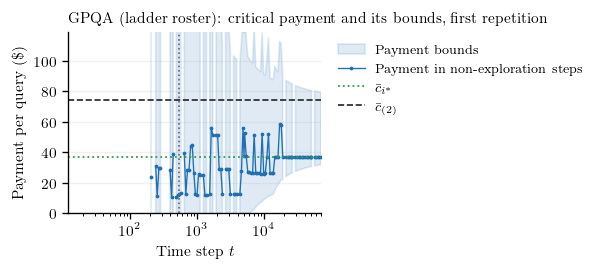

legend: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/legend_payment_bounds.pdf


In [24]:
# Figure: the critical payment of the first repetition at the grid rounds, inside the payment
# bounds of the provider selected in that round.
first = LONG["mechanism"][0]
fig, ax = plt.subplots(figsize=PANEL)
ax.fill_between(GRID, first["bound_lower"], first["bound_upper"], color=STYLE["mechanism"]["color"], alpha=0.14, label="Payment bounds")
ax.plot(GRID, first["payment_at_grid"], color=STYLE["mechanism"]["color"], linewidth=0.8, marker=".", markersize=2.5, label="Payment in non-exploration steps")
ax.axhline(TRUTH.c_star, color=COLOR_ISTAR, linestyle=":", linewidth=1.1, label="$\\bar c_{i^*}$")
ax.axhline(TRUTH.c_second, color="#222", linestyle="--", linewidth=1.0, label="$\\bar c_{(2)}$")
ax.axvline(ONE_PASS, color="#666", linestyle=":", linewidth=1)
if TC.reachable:
    ax.axvline(HORIZON_MARK, color="#888", linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_xlim(N, T_LONG)
ax.set_ylim(0, 1.6 * TRUTH.c_second)   # the upper bound starts at C_max; the region of interest is around c^(2)
ax.set_xlabel("Time step $t$")
ax.set_ylabel("Payment per query (\\$)")
finish(fig, "payment_bounds_long_horizon", title=f"{BENCHMARK} ({ROSTER} roster): critical payment and its bounds, first repetition")

save_legend([
    (Line2D([], [], color=STYLE["mechanism"]["color"], linewidth=0.8, marker=".", markersize=4), "Payment in non-exploration steps"),
    (Patch(facecolor=STYLE["mechanism"]["color"], alpha=0.25, linewidth=0), "Payment bounds"),
    (Line2D([], [], color=COLOR_ISTAR, linestyle=":", linewidth=1.1), "$\\bar c_{i^*}$"),
    (Line2D([], [], color="#222", linestyle="--", linewidth=1.0), "$\\bar c_{(2)}$"),
] + VLINES[:1 + bool(TC.reachable)], "payment_bounds", ncol=3)

figure: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/long_horizon_amount_paid_per_query.pdf


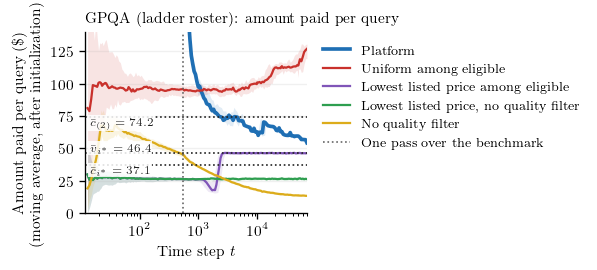

/tmp/ipykernel_2741927/2318181940.py:24: RuntimeWarning: All-NaN slice encountered
  ax.plot(GRID, np.nanmedian(values, axis=0), color=color, linewidth=1.6, label=label)
/NL/strategic-compute/work/svenv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


figure: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/long_horizon_mechanism_economic_quantities.pdf


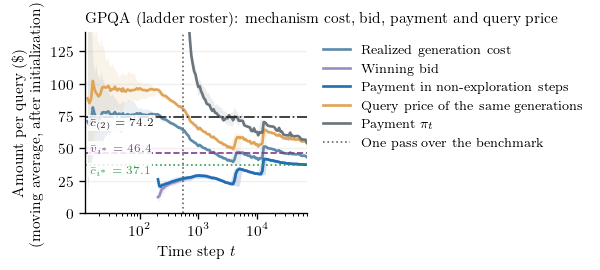

legend: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/legend_economic.pdf


In [25]:
# Figures: amount paid per query under every rule, and the mechanism's generation cost, winning
# bid, critical payment and query price, in a rolling window over the rounds after initialization.
# With forced exploration the first pass is mostly forced rounds paid C_max, so the amount-paid
# axes are cut at 1.6 max{c^(2), query price of i*} or 1.1 times the largest median at T.
PAY_TOP = max(1.6 * max(TRUTH.c_second, TRUTH.price[TRUTH.istar]),
              1.1 * max(float(np.nanmedian([r["rolling_amount_paid"][-1] for r in LONG[name]])) for name in LONG_POLICIES)) if EXPLORING else None
long_figure("rolling_amount_paid", "Amount paid per query (\\$)\n(moving average, after initialization)",
            f"{BENCHMARK} ({ROSTER} roster): amount paid per query", "long_horizon_amount_paid_per_query", ylim=(0, PAY_TOP) if EXPLORING else None,
            lines=[(TRUTH.c_star, f"$\\bar c_{{i^*}} = {TRUTH.c_star:.1f}$", False),
                   (TRUTH.price[TRUTH.istar], f"$\\bar v_{{i^*}} = {TRUTH.price[TRUTH.istar]:.1f}$", True)]
                  + ([(TRUTH.c_second, f"$\\bar c_{{(2)}} = {TRUTH.c_second:.1f}$", False)] if EXPLORING else []))

ECONOMIC = [
    ("rolling_generation_cost_after_init", "Realized generation cost", "#5d8aa8"),
    ("rolling_winning_bid", "Winning bid", "#9b8dc4"),
    ("rolling_mechanism_payment", "Payment in non-exploration steps", "#1f6fb4"),
    ("rolling_query_price_after_init", "Query price of the same generations", "#e0a458"),
]
if EXPLORING:
    ECONOMIC.append(("rolling_amount_paid", "Payment $\\pi_t$", "#6c757d"))
fig, ax = plt.subplots(figsize=PANEL)
for key, label, color in ECONOMIC:
    values = np.array([r[key] for r in LONG["mechanism"]], dtype=float)
    ax.plot(GRID, np.nanmedian(values, axis=0), color=color, linewidth=1.6, label=label)
    ax.fill_between(GRID, np.nanpercentile(values, 10, axis=0), np.nanpercentile(values, 90, axis=0), color=color, alpha=0.13, linewidth=0)
long_marks(ax)
hline(ax, TRUTH.c_star, f"$\\bar c_{{i^*}} = {TRUTH.c_star:.1f}$", style=":", color=COLOR_ISTAR, above=False)
hline(ax, TRUTH.c_second, f"$\\bar c_{{(2)}} = {TRUTH.c_second:.1f}$", style="-.", above=False)   # below: c^(2) and the query price can be close
if EXPLORING:
    hline(ax, TRUTH.price[TRUTH.istar], f"$\\bar v_{{i^*}} = {TRUTH.price[TRUTH.istar]:.1f}$", style="--", color="#7f3c8d")
if EXPLORING:
    ax.set_ylim(0, PAY_TOP)
ax.set_ylabel("Amount per query (\\$)\n(moving average, after initialization)")
finish(fig, "long_horizon_mechanism_economic_quantities", title=f"{BENCHMARK} ({ROSTER} roster): mechanism cost, bid, payment and query price")

save_legend([(Line2D([], [], color=color, linewidth=1.6), label) for _, label, color in ECONOMIC] + VLINES[:1 + bool(TC.reachable)],
            "economic", ncol=2)

## 6. Manifest

Settings, seeds and the list of output files.

In [26]:
manifest = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "git_commit": git_value("rev-parse", "HEAD"),
    "git_worktree_dirty": bool(git_value("status", "--porcelain")),
    "benchmark": BENCHMARK,
    "roster": ROSTER,
    "environment": ENV.id,
    "quick": QUICK,
    "master_seed": MASTER,
    "draw_seed": draw_seed(MASTER, ENV.id),
    "episode_seeds": [episode_seed(MASTER, ENV.id, rep) for rep in range(max(REPS, LONG_REPS))],
    "one_pass_rounds": ONE_PASS,
    "one_pass_repetitions": REPS,
    "one_pass_policies": POLICIES,
    "long_horizon_rounds": T_LONG,
    "long_horizon_repetitions": LONG_REPS,
    "long_horizon_policies": LONG_POLICIES,
    "checkpoints": CHECKPOINTS,
    "grid": GRID.tolist(),
    "theta": ENV.theta,
    "roster_models": MODELS,
    "c_max": RADII.c_max,
    "delta": RADII.delta,
    "gamma": RADII.gamma,
    "margin_used_to_construct_costs": MARGIN,
    "monetary_unit": "1e-6 USD",
    "amount_paid_definition": {
        "mechanism_and_no_quality_filter": "critical payment under the configured payment rule",
        "listed_price_alternatives": "query price of the selected provider (generated tokens times its listed price)",
        **({"mechanism_with_exploration": "critical payments" + EXPLORATION_BASIS} if EXPLORING else {}),
    },
    "exploration": {
        "arm": ARM.get("mechanism", "mechanism"),
        **describe(VARIANT),
        "description": EXPLORATION_TEXT,
        "note": "selection statistics count every round, forced rounds included",
    },
    "trajectory_summary": "median over repetitions with a 10-90% band; probabilities are fractions of repetitions",
    "figures": sorted(p.name for p in OUT.glob("*.pdf") if not p.name.startswith("legend_")),
    "legends": sorted(p.name for p in OUT.glob("legend_*.pdf")),
    "tables": sorted(p.name for p in OUT.glob("*.csv") if not p.name.endswith("_per_repetition.csv")),
    "per_repetition_results": sorted(p.name for p in OUT.glob("*_per_repetition.csv")),
}
(OUT / "manifest.json").write_text(json.dumps(manifest, indent=2))
print("manifest:", (OUT / "manifest.json").relative_to(ROOT))
for path in sorted(OUT.iterdir()):
    print(f"  {path.name}  ({path.stat().st_size / 1024:.0f} kB)")

manifest: analysis/results/variants/count_scale2_alpha0.75/gpqa/ladder/manifest.json
  economic_quantities.pdf  (576 kB)
  environment.csv  (1 kB)
  exploration_summary.csv  (1 kB)
  legend_bounds.pdf  (165 kB)
  legend_economic.pdf  (233 kB)
  legend_economic_quantities.pdf  (354 kB)
  legend_landscape.pdf  (228 kB)
  legend_payment_bounds.pdf  (324 kB)
  legend_policies_lines.pdf  (165 kB)
  legend_policies_markers.pdf  (165 kB)
  long_horizon_amount_paid_per_query.pdf  (422 kB)
  long_horizon_checkpoints.csv  (9 kB)
  long_horizon_eligible_providers.pdf  (344 kB)
  long_horizon_excess_payment_vs_bound.pdf  (283 kB)
  long_horizon_final_counts_per_repetition.csv  (145 kB)
  long_horizon_generation_cost_per_query.pdf  (393 kB)
  long_horizon_generation_regret_per_round.pdf  (322 kB)
  long_horizon_generation_regret_vs_bound.pdf  (285 kB)
  long_horizon_grid_per_repetition.csv  (9213 kB)
  long_horizon_i_star_identification_probability.pdf  (248 kB)
  long_horizon_mechanism_economic_qu

## 7. Cross-environment summary

One-pass outcomes of every environment under `RESULTS_DIR`, written to `one_pass_summary.csv`.

In [27]:
RESULTS = ROOT / RESULTS_DIR
SUMMARY_METRICS = [
    "unqualified_share", "quality_regret_per_round", "generation_regret_per_round",
    "generation_cost_per_query", "amount_paid_per_query", "istar_share",
]
header = ["benchmark", "roster", "Theta", "|Q|", "i*", "policy", "role", "amount paid basis"]
for key in SUMMARY_METRICS:
    header += [f"{key} mean", f"{key} 95% half-width"]
rows = []
for outcomes in sorted(RESULTS.glob("*/*/one_pass_outcomes.csv")):
    directory = outcomes.parent
    with (directory / "environment.csv").open() as handle:
        constants = dict(csv.reader(handle))
    with outcomes.open() as handle:
        for record in csv.DictReader(handle):
            rows.append([
                directory.parent.name, directory.name, constants["Theta"], constants["qualified providers |Q|"], constants["i*"],
                record["policy"], record["role"], record["amount paid basis"],
                *[float(record[f"{key} {stat}"]) for key in SUMMARY_METRICS for stat in ("mean", "95% half-width")],
            ])
show(["benchmark", "roster", "policy", *SUMMARY_METRICS], [[row[0], row[1], row[5], *row[8::2]] for row in rows])
path = RESULTS / "one_pass_summary.csv"
with path.open("w", newline="") as handle:
    csv.writer(handle).writerows([header, *rows])
print("table:", path.relative_to(ROOT))

benchmark  roster                  policy  unqualified_share  quality_regret_per_round  generation_regret_per_round  generation_cost_per_query  amount_paid_per_query  istar_share
     gpqa    full               mechanism             0.1852                    0.0052                      14.2190                    27.4491                64.4341       0.2138
     gpqa    full        uniform_eligible             0.1124                    0.0031                      18.8449                    31.9483                39.9354       0.1088
     gpqa    full  cheapest_rate_eligible             0.0018                    0.0001                      10.7167                    23.7020                29.6275       0.0018
     gpqa    full          cheapest_price             0.0018                    0.0001                      10.7167                    23.7020                29.6275       0.0018
     gpqa    full       no_quality_filter             0.2326                    0.0065                   